Обучение моделей определению тональности (положительный, нейтральный, отрицательный) комментариев

In [55]:
!conda install xgboost

^C


In [56]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV


from catboost import CatBoostClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier



### Классы:

0 - нейтральный

1 - позитивный 

2 - негативный

In [57]:
dataset = pd.read_csv("../src/data/data.csv")

In [58]:
dataset.columns

Index(['Unnamed: 0', 'cleaned_review', 'sentiments'], dtype='object')

In [59]:
dataset.shape

(17337, 3)

In [60]:
dataset["sentiments"].value_counts()

sentiments
1    9503
0    6300
2    1534
Name: count, dtype: int64

In [61]:
data_neutral= dataset[dataset["sentiments"] == 0]
data_pos = dataset[dataset["sentiments"] == 1]
data_negative = dataset[dataset["sentiments"] == 2]

In [62]:
def metrics(val, preds, title):
    print(f"{title}:")
    print(f"Точность: {accuracy_score(val, preds)}")
    print(f"f1: {f1_score(val, preds, average = "macro")}")

In [63]:
def bar_plot(values):
    plt.figure(figsize=(10, 6))
    plt.grid(True)
    plt.title("Соотношение положительных и отрицательных отзывов")
    names = ["neutral", "positive", "negative"]

    plt.bar(names, values)
    plt.show()

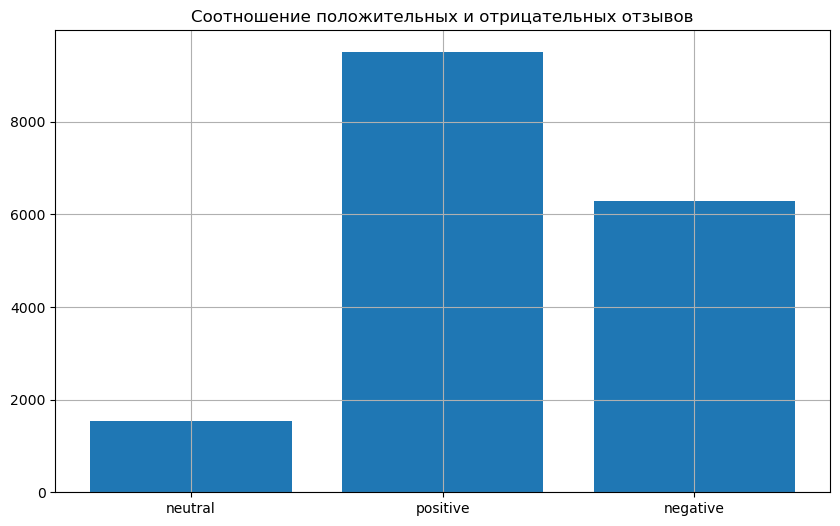

In [64]:
bar_plot([data_negative .shape[0], data_pos.shape[0], data_neutral.shape[0]])

### Разделение данных

In [65]:
X, y = dataset["cleaned_review"], dataset["sentiments"]

In [66]:
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.2, stratify=y_train_temp)

### Базовая модель LinearSVC

In [67]:
base_pipeline = Pipeline([
    ("tfid", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english", min_df = 2)),
    ("cclf", CalibratedClassifierCV(estimator = LinearSVC(C=1.0, max_iter=10000,  class_weight='balanced', loss = 'squared_hinge'), cv = 5))
])

base_pipeline.fit(X_train, y_train)

baseline_predict = base_pipeline.predict(X_val)
baseline_predict_proba = base_pipeline.predict_proba(X_val)

accuracy_baseline = accuracy_score(y_val, baseline_predict)
f1_baseline = f1_score(y_val, baseline_predict, average = "macro")

# print(baseline_predict_proba.round(3))

In [ ]:
def predict_model(model_pipeline, text):
    proba = model_pipeline.predict([text])
    return proba

In [ ]:
metrics(y_val, baseline_predict, "LinearSVC")

LinearSVC:
Точность: 0.8428262436914203
f1: 0.7873924073816451


Улучшение базовой модели с помощью RandomizerSearchCV 

In [ ]:
baseline_dict = {
    "tfid__max_features": [5000, 10000, 15000],
    "tfid__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfid__min_df": [1, 2, 3],
    "svc__C": [0.1, 1.0, 10.0],
    "svc__loss": ["hinge", "squared_hinge"]
}

In [ ]:
random_search = RandomizedSearchCV(
    base_pipeline,
    param_distributions = baseline_dict,
    n_iter = 30,
    cv = 3,
    scoring = "f1",
    n_jobs = -1
)

In [ ]:
random_search.fit(X_train, y_train)
print(f"Лучшие параметры: {random_search.best_params_}")

c:\Users\s7omb\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Лучшие параметры: {'tfid__ngram_range': (1, 1), 'tfid__min_df': 1, 'tfid__max_features': 5000, 'svc__loss': 'hinge', 'svc__C': 0.1}


### Логистическая регрессия

In [ ]:
pipe = Pipeline([
    ("tfid", TfidfVectorizer(max_features=10000, stop_words="english")),
    ("lt", LogisticRegression(max_iter = 1000, class_weight = "balanced"))
])

pipe.fit(X_train, y_train)
ls_preds = pipe.predict(X_val)



In [ ]:
metrics(y_val, ls_preds, "Логистическая регрессия")

Логистическая регрессия:
Точность: 0.8100216294160058
f1: 0.7590535735712679


### Catboost

In [ ]:
df_train = pd.DataFrame({'text': X_train, 'label': y_train})
df_val = pd.DataFrame({'text': X_val, 'label': y_val})

In [ ]:
cat_boost = CatBoostClassifier(
    iterations = 500,
    depth = 5,
    learning_rate = 0.1,
    loss_function = "MultiClass",
    early_stopping_rounds = 50
)

cat_boost.fit(    
    df_train[["text"]], 
    y = df_train["label"],
    text_features=['text'], 
    eval_set=[(df_val[['text']], df_val['label'])],
    use_best_model = True
)

cat_predict = cat_boost.predict(df_val[["text"]])

0:	learn: 1.0152458	test: 1.0140935	best: 1.0140935 (0)	total: 203ms	remaining: 1m 41s
1:	learn: 0.9456217	test: 0.9427055	best: 0.9427055 (1)	total: 285ms	remaining: 1m 10s
2:	learn: 0.8952517	test: 0.8914360	best: 0.8914360 (2)	total: 372ms	remaining: 1m 1s
3:	learn: 0.8535938	test: 0.8488200	best: 0.8488200 (3)	total: 449ms	remaining: 55.7s
4:	learn: 0.8175543	test: 0.8114262	best: 0.8114262 (4)	total: 528ms	remaining: 52.2s
5:	learn: 0.7847839	test: 0.7777704	best: 0.7777704 (5)	total: 604ms	remaining: 49.7s
6:	learn: 0.7567343	test: 0.7476913	best: 0.7476913 (6)	total: 677ms	remaining: 47.7s
7:	learn: 0.7333603	test: 0.7232265	best: 0.7232265 (7)	total: 747ms	remaining: 45.9s
8:	learn: 0.7151920	test: 0.7042842	best: 0.7042842 (8)	total: 821ms	remaining: 44.8s
9:	learn: 0.6988157	test: 0.6878481	best: 0.6878481 (9)	total: 900ms	remaining: 44.1s
10:	learn: 0.6836942	test: 0.6723844	best: 0.6723844 (10)	total: 982ms	remaining: 43.6s
11:	learn: 0.6705707	test: 0.6591792	best: 0.65917

KeyboardInterrupt: 

In [ ]:
metrics(df_val['label'], cat_predict, "CatBoost")

CatBoost:
Точность: 0.8485940879596251
f1: 0.7865224519070674


###  Multinomial Naive Bayes

In [ ]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000, 
        ngram_range=(1,2), 
        stop_words="english")),

    ("nb", MultinomialNB(
        alpha=0.01, 
        class_prior=None, 
        fit_prior=True))
])

nb_pipeline.fit(X_train, y_train)

nb_predict = nb_pipeline.predict(X_val)

In [ ]:
np_param_grid = {
    "nb__alpha": [0.01, 0.1, 0.5, 1.0, 2.0],
    "tfidf__ngram_range": [(1,2), (1,2), (2,2), (1,3)]
}

In [ ]:
nb_search = GridSearchCV(
    nb_pipeline,
    np_param_grid,
    cv = 3, 
    scoring = "f1",
    n_jobs = -1)

nb_search.fit(X_train, y_train)

c:\Users\s7omb\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


,estimator,Pipeline(step...(alpha=0.1))])
,param_grid,"{'nb__alpha': [0.01, 0.1, ...], 'tfidf__ngram_range': [(1, ...), (1, ...), ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [ ]:
nb_search.best_params_

{'nb__alpha': 0.01, 'tfidf__ngram_range': (1, 2)}

In [ ]:
metrics(y_val, nb_predict, "MultinomialNB")

MultinomialNB:
Точность: 0.7591925018024513
f1: 0.6862395079125196
